### Surprisal Analysis
March 31, 2026

Models: GPT-2 / Gemma
Unidirectional vs. Bidirectional (Bayesian) Surprisal.

Bidirectional Implementation:
$$
P(w_t|w_{1:t-1}, w_{t+1:n})=\frac{P(w_{t:n} |w_{1:t-1})}{\sum_{w \in \mathcal{V}}P(w, w_{t+1:n} |w_{1:t-1})}
$$

In [1]:
import torch
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("data_output/bk21_with_gpt2.csv")

/var/folders/xj/wy41h91s58s940n_b2f9wj4m0000gn/T/ipykernel_84553/2562263521.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df['gpt2_uni_surprisal'], label='Unidirectional', fill=True)
/var/folders/xj/wy41h91s58s940n_b2f9wj4m0000gn/T/ipykernel_84553/2562263521.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df['gpt2_bi_surprisal'], label='Bidirectional', fill=True)
/var/folders/xj/wy41h91s58s940n_b2f9wj4m0000gn/T/ipykernel_84553/2562263521.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


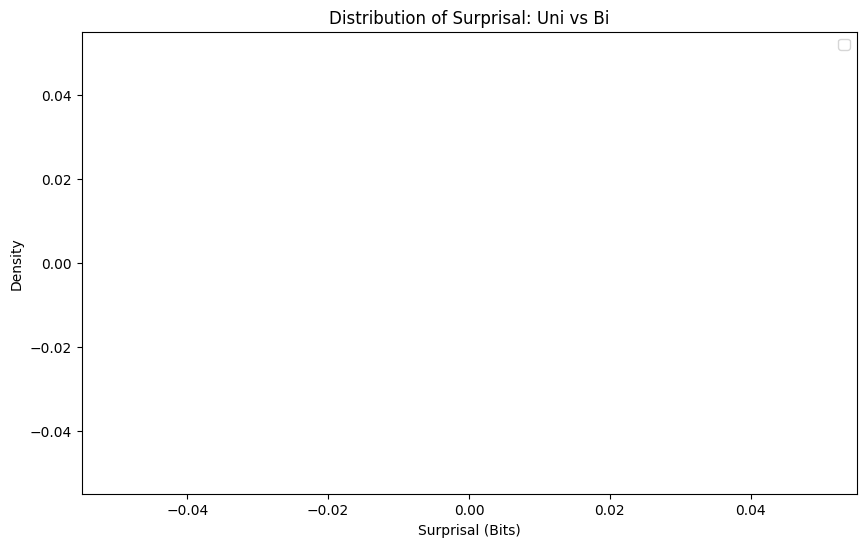

In [5]:
# surprisal distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(df['gpt2_uni_surprisal'], label='Unidirectional', fill=True)
sns.kdeplot(df['gpt2_bi_surprisal'], label='Bidirectional', fill=True)
plt.title("Distribution of Surprisal: Uni vs Bi")
plt.xlabel("Surprisal (Bits)")
plt.ylabel("Density")
plt.legend()
plt.show()

/var/folders/xj/wy41h91s58s940n_b2f9wj4m0000gn/T/ipykernel_84553/2260481756.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='condition', y='gpt2_bi_surprisal', palette='viridis')


UnboundLocalError: local variable 'boxprops' referenced before assignment

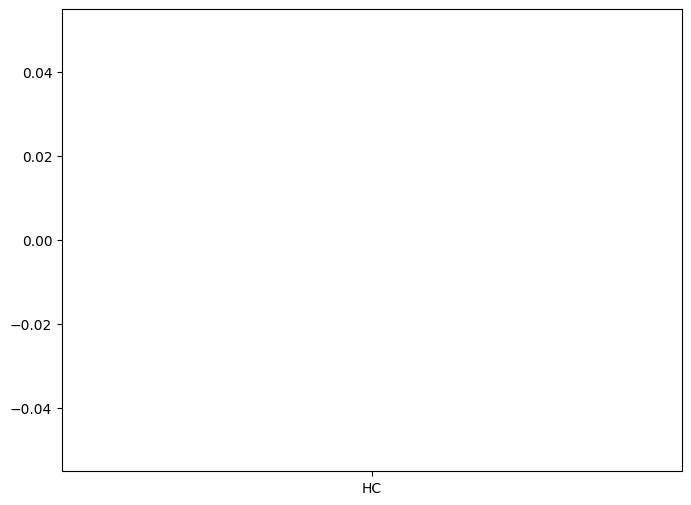

In [6]:
# condition comparison
# does the model distinguish between High Constancy (HC) and Low Constancy (LC)?
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='condition', y='gpt2_bi_surprisal', palette='viridis')
plt.title("Bidirectional Surprisal by Stimulus Condition")
plt.show()

In [7]:
# metadata inspection 
metadata = torch.load("data_output/bk21_with_gpt2_metadata.pt")
sample_row = metadata[0]['data']

print(f"Model: {sample_row['model_id']}")
print(f"Total Uni Surprisal: {sample_row['uni_total_surprisal']:.4f}")
print(f"Number of target tokens: {len(sample_row['token_data'])}")
print(f"Logit Vector Shape: {sample_row['token_data'][0]['logits'].shape}")

IndexError: list index out of range

In [8]:
# stats
summary = df.groupby('condition')[['gpt2_uni_surprisal', 'gpt2_bi_surprisal']].agg(['mean', 'std'])
print("Summary Table")
print(summary)

Summary Table
          gpt2_uni_surprisal     gpt2_bi_surprisal    
                        mean std              mean std
condition                                             
HC                       NaN NaN               NaN NaN
LC                       NaN NaN               NaN NaN
MC                       NaN NaN               NaN NaN
